<a href="https://colab.research.google.com/github/leydasfs/PDI/blob/main/P7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from google.colab import files

# Subir imagen
uploaded = files.upload()

img = cv2.imread('P7 (4).jpg')

# Verificar carga
if img is None:
    print("Error: no se encontró la imagen")
else:
    print("Imagen cargada correctamente")

# Convertir a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Saving P7.jpg to P7 (4).jpg
Imagen cargada correctamente


Separar canales RGB


In [32]:
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

Mostrar imagen y canales

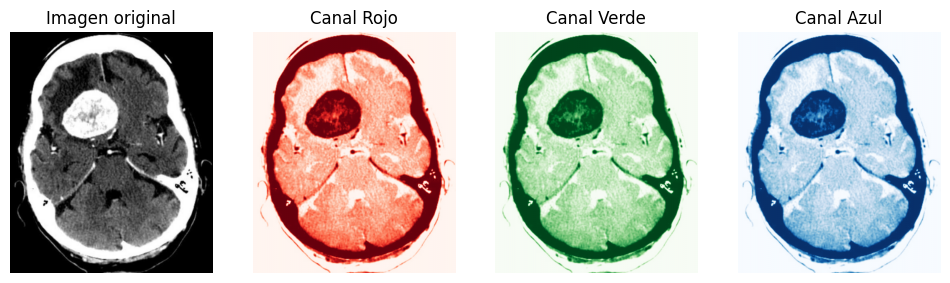

In [33]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(R, cmap='Reds')
plt.title('Canal Rojo')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(G, cmap='Greens')
plt.title('Canal Verde')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(B, cmap='Blues')
plt.title('Canal Azul')
plt.axis('off')

plt.show()

Segmentacion sencilla

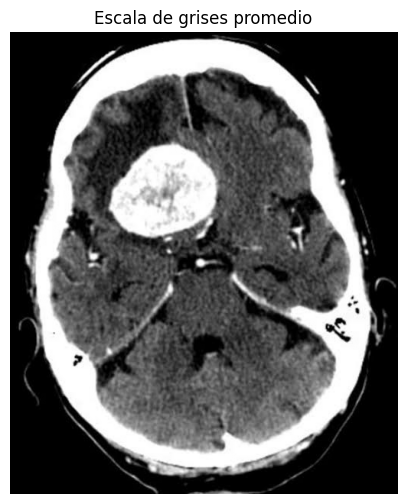

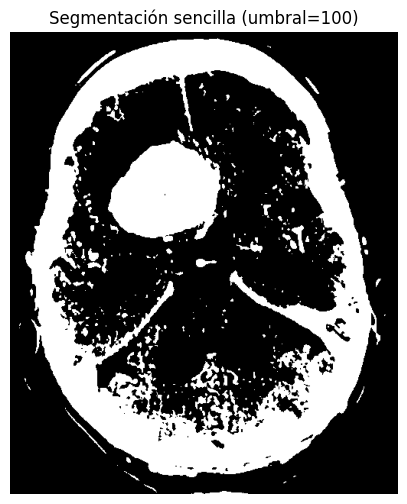

In [ ]:
gray_avg = ((R.astype(np.float32) + G + B) / 3).astype(np.uint8)

# Mostrar escala de grises
plt.figure(figsize=(6,6))
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises promedio')
plt.axis('off')
plt.show()

# Umbral binario
umbral = 100

_, seg_standard = cv2.threshold(gray_avg,
                                umbral,
                                255,
                                cv2.THRESH_BINARY)

# Mostrar segmentación
plt.figure(figsize=(6,6))
plt.imshow(seg_standard, cmap='gray')
plt.title(f'Segmentación sencilla (umbral={umbral})')
plt.axis('off')
plt.show()

Segmentacion optima

In [ ]:
# Normalizar canales RGB
R_norm = R.astype(np.float32) / 255
G_norm = G.astype(np.float32) / 255
B_norm = B.astype(np.float32) / 255

In [ ]:
# Función objetivo
def grayscale_variance(weights):

    w_r, w_g, w_b = weights

    gray = (w_r * R_norm +
            w_g * G_norm +
            w_b * B_norm)

    gray_normalized = ((gray - gray.min()) /
                       (gray.max() - gray.min()))

    return -np.var(gray_normalized)

In [ ]:
# Restricción
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
})

# Límites
bounds = [(0,1), (0,1), (0,1)]

# Valores iniciales
initial_weights = [0.33, 0.33, 0.34]

In [ ]:
# Optimización SLSQP
result = minimize(grayscale_variance,
                  initial_weights,
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)

# Pesos óptimos
optimal_weights = result.x

print("Pesos óptimos:")
print(optimal_weights)

Pesos óptimos:
[0.33 0.33 0.34]


Escala de grises optima

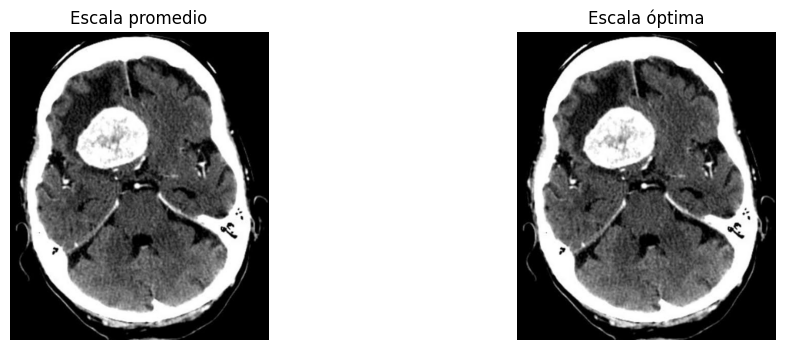

In [ ]:
# Crear imagen óptima
gray_optimal = (
    optimal_weights[0] * R_norm +
    optimal_weights[1] * G_norm +
    optimal_weights[2] * B_norm
)

gray_optimal = (gray_optimal * 255).astype(np.uint8)

# Mostrar comparación
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala promedio')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray_optimal, cmap='gray')
plt.title('Escala óptima')
plt.axis('off')

plt.show()

Segmentacion optima

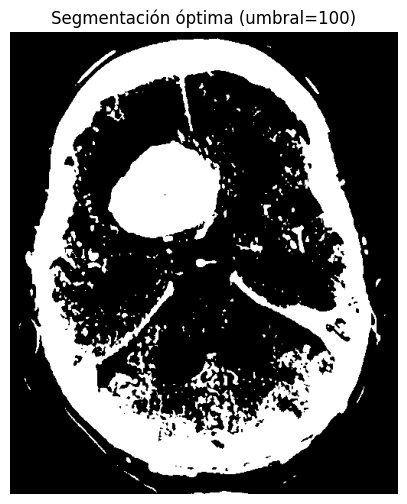

In [ ]:
# Segmentación binaria óptima
_, seg_optimal = cv2.threshold(gray_optimal,
                               umbral,
                               255,
                               cv2.THRESH_BINARY)

# Mostrar resultado
plt.figure(figsize=(6,6))
plt.imshow(seg_optimal, cmap='gray')
plt.title(f'Segmentación óptima (umbral={umbral})')
plt.axis('off')
plt.show()

Eliminar ruido

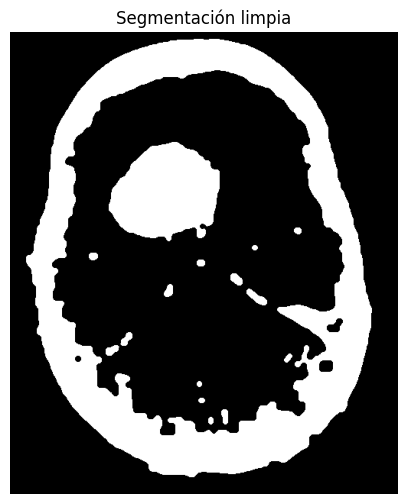

In [ ]:
# Kernel
kernel = np.ones((7,7), np.uint8)

# Apertura
seg_clean = cv2.morphologyEx(seg_optimal,
                             cv2.MORPH_OPEN,
                             kernel)

# Cierre
seg_clean = cv2.morphologyEx(seg_clean,
                             cv2.MORPH_CLOSE,
                             kernel)

# Filtro mediana
seg_clean = cv2.medianBlur(seg_clean, 5)

# Mostrar imagen limpia
plt.figure(figsize=(6,6))
plt.imshow(seg_clean, cmap='gray')
plt.title('Segmentación limpia')
plt.axis('off')
plt.show()

Detectar contornos

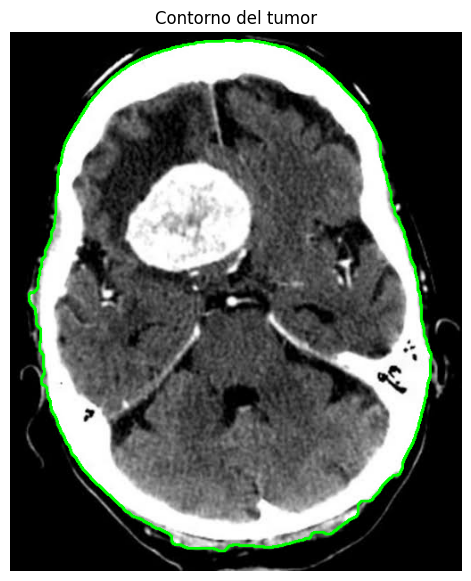

In [ ]:
# Encontrar contornos
contours, _ = cv2.findContours(seg_clean,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

# Copia de imagen original
img_contours = img_rgb.copy()

# Contorno principal
largest_contour = max(contours,
                      key=cv2.contourArea)

# Dibujar contorno
cv2.drawContours(img_contours,
                 [largest_contour],
                 -1,
                 (0,255,0),
                 2)

# Mostrar resultado
plt.figure(figsize=(7,7))
plt.imshow(img_contours)
plt.title('Contorno del tumor')
plt.axis('off')
plt.show()

Area del tumor

In [ ]:
# Área del tumor
tumor_area = cv2.contourArea(largest_contour)

print("Área estimada del tumor:")
print(tumor_area, "pixeles")

Área estimada del tumor:
200272.5 pixeles


Coeficientes optimos

In [ ]:
print("Pesos óptimos RGB:")

print("Peso R =", optimal_weights[0])
print("Peso G =", optimal_weights[1])
print("Peso B =", optimal_weights[2])

Pesos óptimos RGB:
Peso R = 0.33
Peso G = 0.33
Peso B = 0.34
